# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/Delhi_AQIBulletins.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Sort data
df = df.sort_values('date')

# Select required columns
df = df[['date', 'index value']]

# Handle missing values
df['index value'] = df['index value'].fillna(method='ffill')

# Extract month
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

C:\Users\gprab\AppData\Local\Temp\ipykernel_17244\490176288.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['index value'] = df['index value'].fillna(method='ffill')


# 3. Monthly Average AQI (CORE TASK)

In [3]:
monthly_avg = df.groupby(['month', 'month_name'])['index value'].mean().reset_index()

# Sort by month
monthly_avg = monthly_avg.sort_values('month')

monthly_avg

,month,month_name,index value
0,1,January,316.125000
1,2,February,254.654867
2,3,March,196.147541
3,4,April,209.570833
4,5,May,204.949640
5,6,June,172.399240
6,7,July,108.633700
7,8,August,103.415162
8,9,September,123.888889
9,10,October,242.945652


# 4. Identify High Pollution Months

In [4]:
# Define threshold (can adjust)
high_threshold = monthly_avg['index value'].mean()

high_pollution_months = monthly_avg[monthly_avg['index value'] > high_threshold]

print("High Pollution Months:\n")
print(high_pollution_months[['month_name', 'index value']])

High Pollution Months:

   month_name  index value
0     January   316.125000
1    February   254.654867
9     October   242.945652
10   November   348.646840
11   December   334.913978


# 5. Categorize Months (Clean / Moderate / High)

In [5]:
def categorize_aqi(aqi):
    if aqi <= 100:
        return "Clean"
    elif aqi <= 200:
        return "Moderate"
    else:
        return "High Pollution"

monthly_avg['category'] = monthly_avg['index value'].apply(categorize_aqi)

monthly_avg

,month,month_name,index value,category
0,1,January,316.125000,High Pollution
1,2,February,254.654867,High Pollution
2,3,March,196.147541,Moderate
3,4,April,209.570833,High Pollution
4,5,May,204.949640,High Pollution
5,6,June,172.399240,Moderate
6,7,July,108.633700,Moderate
7,8,August,103.415162,Moderate
8,9,September,123.888889,Moderate
9,10,October,242.945652,High Pollution


# 6. Visualization (Monthly AQI Pattern)

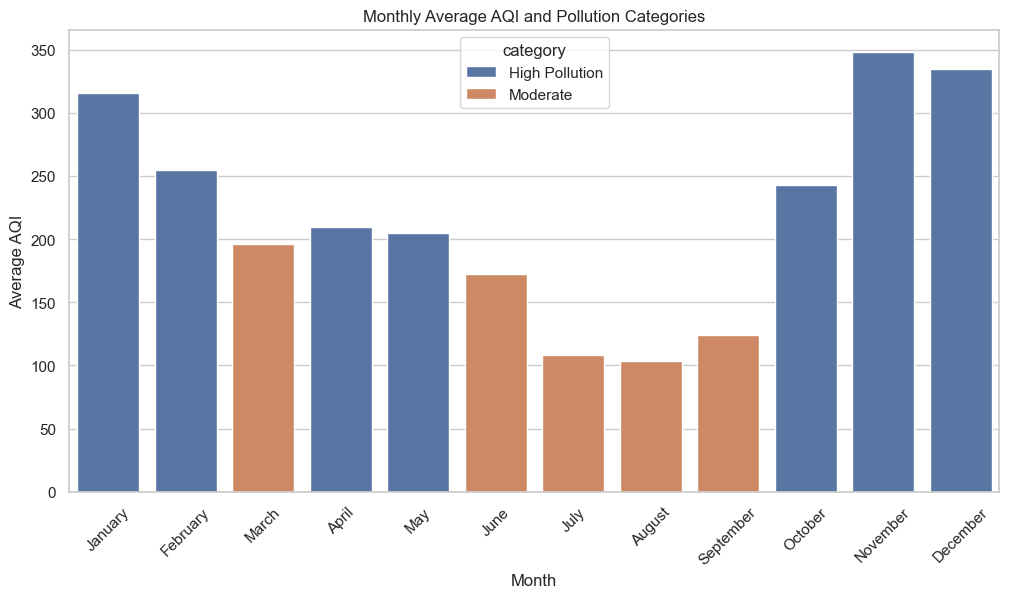

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='month_name',
    y='index value',
    hue='category',
    data=monthly_avg,
    dodge=False
)

plt.title("Monthly Average AQI and Pollution Categories")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)
plt.show()

# 7. AI-Based Seasonal Insight Generator

In [8]:
def generate_insight(df):
    high = df[df['category'] == 'High Pollution']['month_name'].tolist()
    moderate = df[df['category'] == 'Moderate']['month_name'].tolist()
    clean = df[df['category'] == 'Clean']['month_name'].tolist()

    insight = "\nSeasonal Pollution Insights:\n"

    if high:
        insight += f"High pollution is observed in: {', '.join(high)}.\n"
    
    if moderate:
        insight += f"Moderate pollution occurs during: {', '.join(moderate)}.\n"
    
    if clean:
        insight += f"Cleaner air quality is observed in: {', '.join(clean)}.\n"

    insight += "\nPollution tends to increase due to seasonal and environmental factors such as weather conditions, temperature inversion, and human activities."

    return insight

print(generate_insight(monthly_avg))


Seasonal Pollution Insights:
High pollution is observed in: January, February, April, May, October, November, December.
Moderate pollution occurs during: March, June, July, August, September.

Pollution tends to increase due to seasonal and environmental factors such as weather conditions, temperature inversion, and human activities.


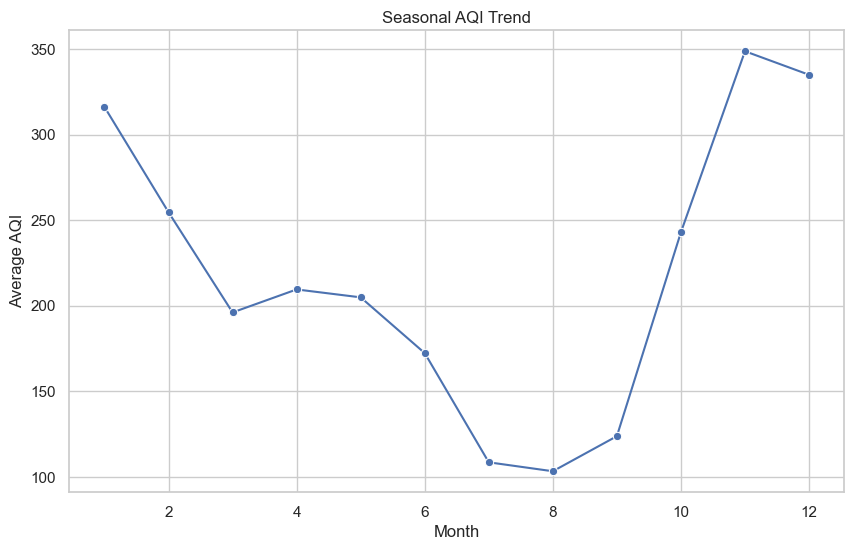

In [9]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x='month',
    y='index value',
    data=monthly_avg,
    marker='o'
)

plt.title("Seasonal AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()